# 23CSE301 Machine Learning - Capstone Project
## Regression Track - Student Performance

**Track owner:** _(name - see `docs/team_contributions.md`)_
**Review:** Review 1 (full track)
**Dataset:** Student Performance (Multiple Linear Regression) - `Student_Performance.csv`
**Source:** https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

---

### How to read this notebook

Each algorithm has its **own section**: first a short explanation of what it is
and how it works, then the code that builds and trains *that* model on our data,
then its result. Every model uses the same train/test split created in section 3,
which is what makes the comparison tables fair.

Pipeline steps come from `src/`, the same code `scripts/run_all.py` runs, so the
notebook and the scripts cannot drift apart.

**AI assistance:** code scaffolding was AI-generated (see `README.md`,
AI-Assistance Disclosure). Every **TEAM TO COMPLETE** cell must be written by the
team and is empty on purpose.

## 0. Setup

In [4]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # project root on the path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

from src import config, data_loading as dl, preprocessing as pp
from src import feature_engineering as fe, evaluation as ev, plotting as pl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("default")                  # warnings stay visible

print("random_state =", config.RANDOM_STATE,
      "| test_size =", config.TEST_SIZE,
      "| cv folds =", config.CV_FOLDS)

random_state = 42 | test_size = 0.2 | cv folds = 5


In [5]:
TARGET = 'Performance Index'
NUM = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
CAT = ['Extracurricular Activities']
print("target          :", TARGET)
print("numeric inputs  :", NUM)
print("categorical inpt:", CAT)

target          : Performance Index
numeric inputs  : ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
categorical inpt: ['Extracurricular Activities']


## 1. Data loading and audit  *(Rubric A1)*

The raw CSV is read from `data/raw/` and never modified. We report shape,
dtypes, missing-value counts and the target distribution.

In [6]:
raw = dl.load_raw("regression")
summary = dl.audit_summary(raw, "regression")
for k, v in summary.items():
    print(f"  {k}: {v}")

[load_raw] regression: Student_Performance.csv -> shape (10000, 6) (expected (10000, 6))
  track: regression
  shape: (10000, 6)
  n_duplicate_rows: 127
  total_missing_cells: 0
  columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
  target: Performance Index
  target_present: True
  target_describe: {'count': 10000.0, 'mean': 55.2248, 'std': 19.212557799463344, 'min': 10.0, '25%': 40.0, '50%': 55.0, '75%': 71.0, 'max': 100.0}


In [7]:
dl.audit(raw, "regression", "raw")

,column,dtype,missing,missing_pct,n_unique,example
0,Hours Studied,int64,0,0.0,9,7
1,Previous Scores,int64,0,0.0,60,99
2,Extracurricular Activities,str,0,0.0,2,Yes
3,Sleep Hours,int64,0,0.0,6,9
4,Sample Question Papers Practiced,int64,0,0.0,10,1
5,Performance Index,float64,0,0.0,91,91.0


In [8]:
raw.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [9]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,NaN,NaN,NaN,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,NaN,NaN,NaN,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Extracurricular Activities,10000,2,No,5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Hours,10000.0,NaN,NaN,NaN,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,NaN,NaN,NaN,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,NaN,NaN,NaN,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


### 1.1 Duplicate rows - a decision for the team

127 exact duplicate rows exist. All five inputs are low-cardinality integers or
a binary flag, so identical rows arise by chance in a 10,000-row synthetic
sample. Removing them leaves 9,873 rows, **below the 10,000-row working
preference**. The reported run **retains** them; both options are measured below.

In [10]:
df = dl.prepare("regression", raw)
dedup = pp.drop_exact_duplicates(df)
print(f"\nretained : {len(df)} rows  (the reported configuration)")
print(f"if dropped: {len(dedup)} rows  -> below the 10,000 preference: {len(dedup) < 10000}")

combos = 1
for c in NUM + CAT:
    combos *= df[c].nunique()
print(f"\ndistinct input combinations possible: {combos:,}")
print(f"rows drawn from those combinations   : {len(df):,}")

[prepare] regression: raw (10000, 6) -> prepared (10000, 6) (6 columns kept)
  excluded: []
[dedup] 10000 -> 9873 rows (127 exact duplicates removed)

retained : 10000 rows  (the reported configuration)
if dropped: 9873 rows  -> below the 10,000 preference: True

distinct input combinations possible: 64,800
rows drawn from those combinations   : 10,000


> ### TEAM TO COMPLETE - Duplicate-handling decision (Q-RG1)
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Given that many distinct input combinations, how many identical rows would you EXPECT by chance in 10,000 draws?
> 2. Coincidence, or a data-collection artefact?
> 3. Which option do you choose, and why?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 2. Exploratory data analysis  *(Rubric A2, A3)*

Distribution plot per input feature, correlation heatmap, target distribution,
and two feature-target scatter plots.

In [11]:
p = pl.distribution_grid(df[NUM + CAT],
                         "Student Performance - input feature distributions",
                         "nb_reg_feature_distributions", "regression")

[fig] results\figures\regression\nb_reg_feature_distributions.png


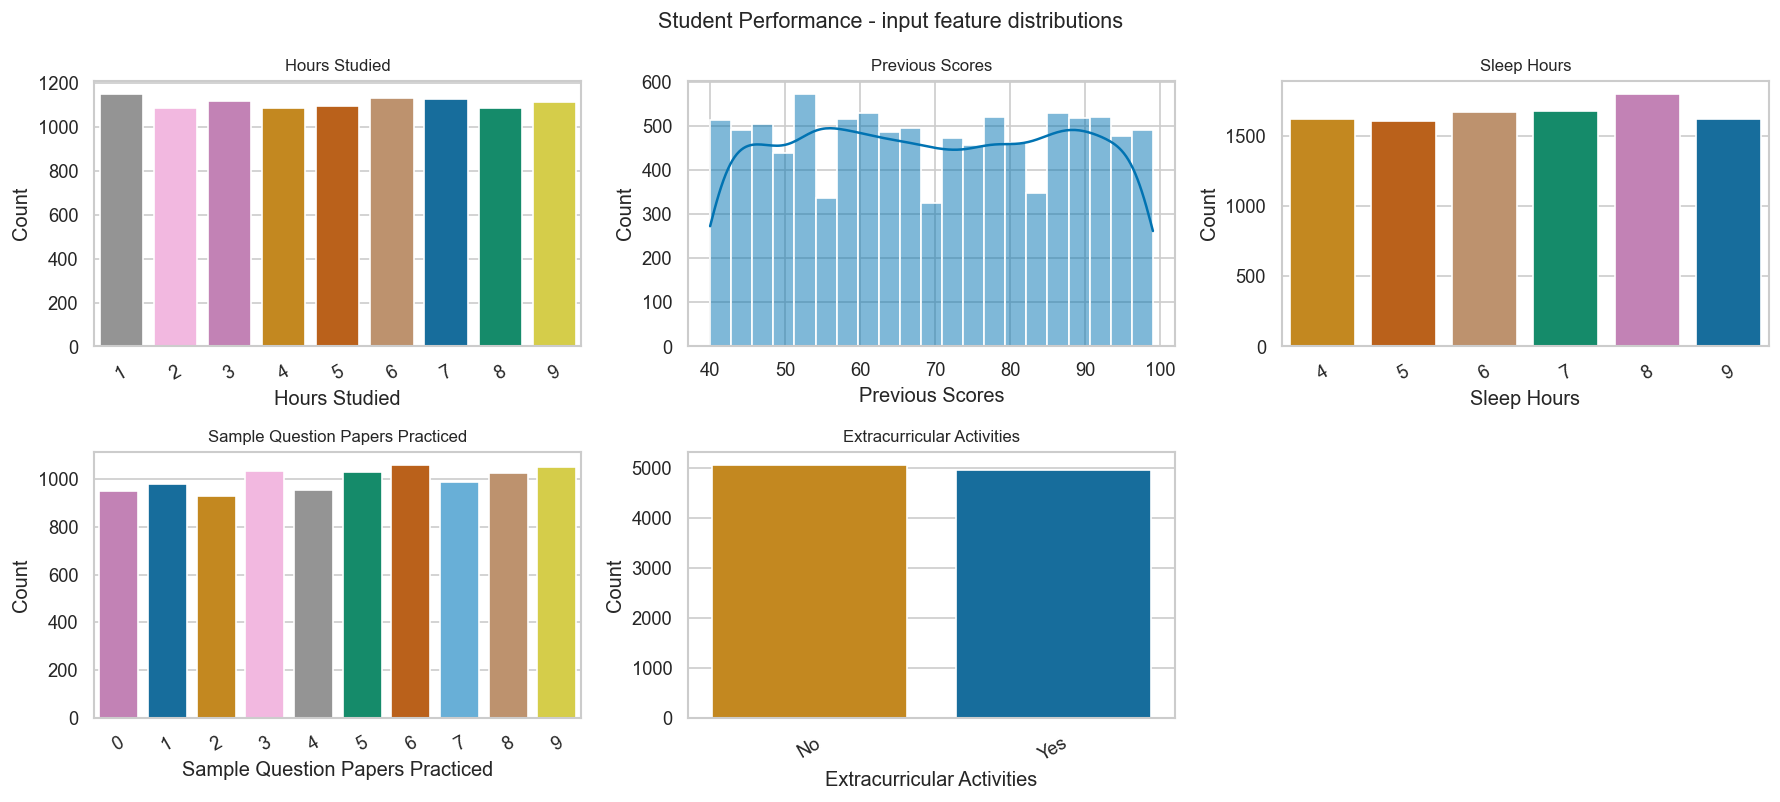

In [12]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Feature distributions
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which features are roughly uniform and which are skewed?
> 2. Does any feature show an implausible value or a suspicious spike?
> 3. What does each shape imply for scaling, or for models that assume normality?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [13]:
p = pl.correlation_heatmap(df, "Student Performance - correlation heatmap (numeric)",
                           "nb_reg_correlation_heatmap", "regression")

[fig] results\figures\regression\nb_reg_correlation_heatmap.png


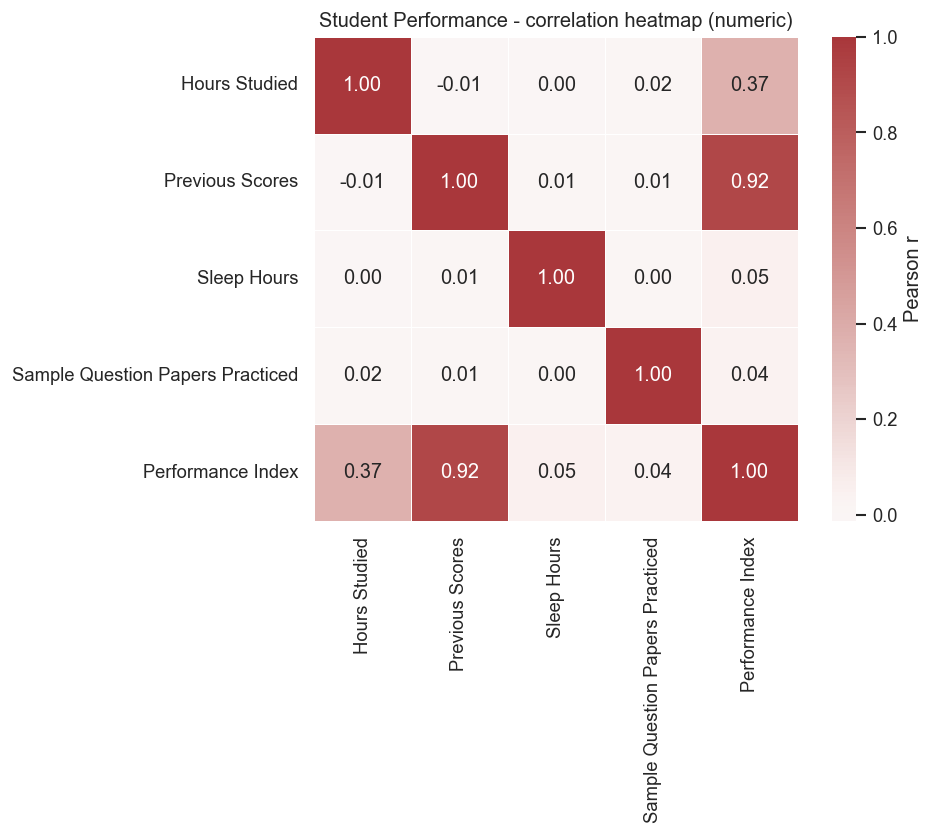

In [14]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [15]:
corr_t = df.select_dtypes("number").corr()[TARGET].drop(TARGET)
print("correlation of each input with the target:")
print(corr_t.round(4).sort_values(ascending=False).to_string())

correlation of each input with the target:
Previous Scores                     0.9152
Hours Studied                       0.3737
Sleep Hours                         0.0481
Sample Question Papers Practiced    0.0433


> ### TEAM TO COMPLETE - Correlation structure
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which input correlates most strongly with Performance Index, and by how much does it lead the others?
> 2. Is any correlation BETWEEN inputs high enough to worry about multicollinearity in the linear models?
> 3. Does the ranking match what you would expect from the domain?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [16]:
p = pl.target_distribution(df[TARGET], "Target distribution - Performance Index",
                           "nb_reg_target_distribution", "regression")

[fig] results\figures\regression\nb_reg_target_distribution.png


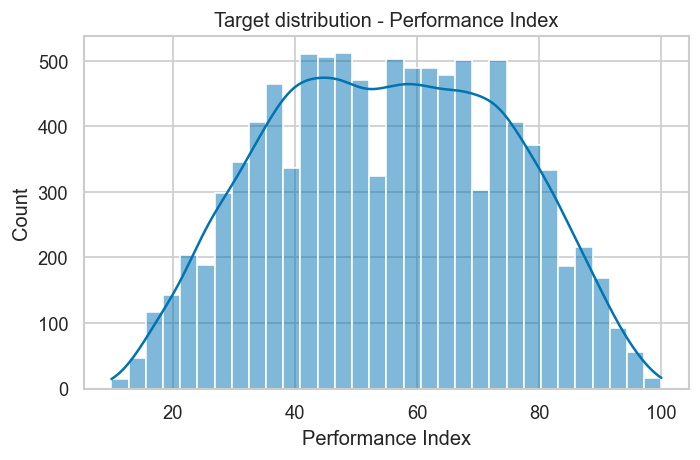

In [17]:
from IPython.display import Image, display
display(Image(filename=str(p)))

In [18]:
top2 = corr_t.abs().sort_values(ascending=False).index[:2].tolist()
print("two strongest relationships with the target:", top2)
p = pl.feature_target_scatter(df, top2, TARGET,
                              "nb_reg_feature_target_scatter", "regression")

two strongest relationships with the target: ['Previous Scores', 'Hours Studied']
[fig] results\figures\regression\nb_reg_feature_target_scatter.png


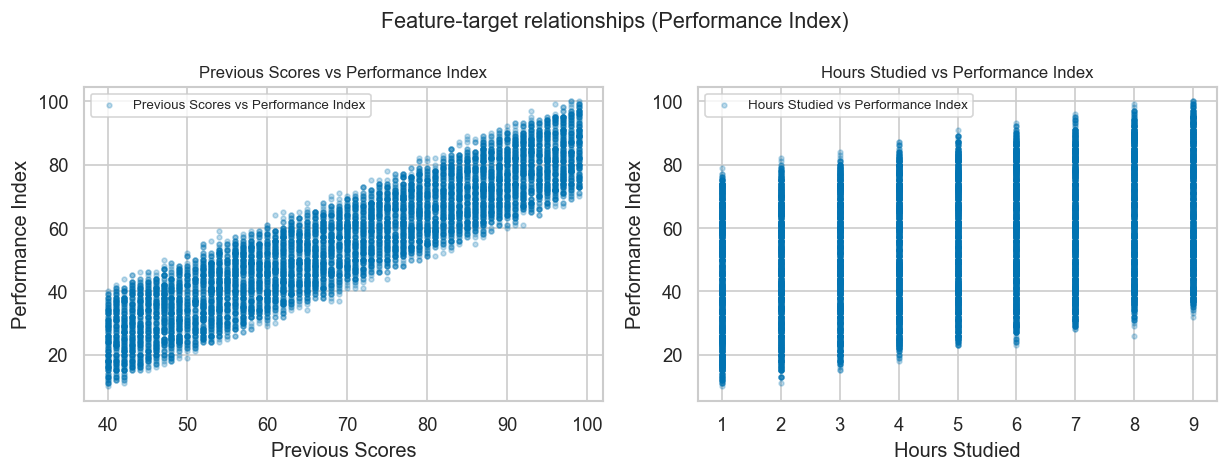

In [19]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Feature-target relationships
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Is each relationship linear, curved, or absent?
> 2. How much vertical spread is there at a fixed x - how much variance can that feature alone NOT explain?
> 3. Does this support a linear model as the baseline?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 3. Preprocessing and the held-out split  *(Rubric B1, B2)*

The split happens **before** any modelling decision, so the test set stays
genuinely unseen.

**Why preprocessing goes inside a Pipeline.** If we scaled the whole dataset
first, the scaler would have computed its mean and standard deviation from the
test rows too - that is data leakage, and section 7.1 makes it a mark deduction.
Inside a `Pipeline`, `.fit()` fits the scaler on training data only, and during
cross-validation it is refitted from scratch on every fold.

**Stratification note.** Rubric B2 asks for a stratified split, but
stratification needs discrete classes and our target is continuous. We use an
unstratified random split and log the ambiguity as **IC-2**.
`pp.split_supervised(..., stratify_bins=k)` implements quantile-binned
stratification if the instructor confirms it is wanted.

In [20]:
X_train, X_test, y_train, y_test = pp.split_supervised(df, TARGET, stratify=False)
print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")
print("overlap check:", pp.check_no_row_leakage(X_train, X_test))

[split] train=(8000, 5) test=(2000, 5) stratify=none

train: (8000, 5)   test: (2000, 5)
overlap check: {'test_rows': 2000, 'test_rows_also_in_train': 258, 'pct': 12.9}


In [21]:
# What the preprocessor actually does, shown once.
prep = pp.make_preprocessor(NUM, CAT, scale=True)
prep.fit(X_train)                                   # TRAINING data only
print("output feature names:", list(prep.get_feature_names_out()))
print("\nnumeric block   : median impute -> StandardScaler")
print("categorical block: most-frequent impute -> OneHotEncoder(drop='if_binary')")
Xt = prep.transform(X_train)
print("\ntraining data after transform - mean ~0, std ~1:")
print("  mean:", np.round(Xt[:, :len(NUM)].mean(axis=0), 6))
print("  std :", np.round(Xt[:, :len(NUM)].std(axis=0), 6))

output feature names: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities_Yes']

numeric block   : median impute -> StandardScaler
categorical block: most-frequent impute -> OneHotEncoder(drop='if_binary')

training data after transform - mean ~0, std ~1:
  mean: [ 0. -0.  0. -0.]
  std : [1. 1. 1. 1.]


> ### TEAM TO COMPLETE - Train/test overlap (Q-RG2)
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Why is the overlap percentage this large here, and is it 'leakage' in the harmful sense?
> 2. Would deduplicating before splitting change your answer?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

### 3.1 Feature engineering  *(Rubric B3)* - NOT YET SATISFIED

`src/feature_engineering.py` ships **empty on purpose**. Until the team registers
a feature *and its justification*, the baseline pipeline runs and this rubric
item reports INCOMPLETE.

In [22]:
fe.status("regression")

{'track': 'regression',
 'state': 'AWAITING TEAM INPUT',
 'rubric_B3': 'INCOMPLETE',
 'detail': 'No engineered feature registered; baseline pipeline executed.'}

> ### TEAM TO COMPLETE - Engineered feature (Q-RG3) - required for rubric B3
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which new feature will you create, from which existing columns?
> 2. Why do you expect it to help? Write this BEFORE you measure it.
> 3. After registering it in src/feature_engineering.py and re-running, did it help? Report honestly either way.
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 4. The ten regression algorithms  *(Rubric C1)*

Each gets its own section below: what it is, how it works, the code that trains
it on our data, and its result. All ten use the same `X_train` / `X_test` from
section 3.

The helper below records each result so section 5 can assemble the comparison
table.

In [23]:
results = {}     # model name -> metrics dict
fitted  = {}     # model name -> fitted Pipeline

def record(name, model):
    """Evaluate a fitted pipeline on the held-out test set and store it."""
    m = ev.regression_metrics(y_test, model.predict(X_test))
    m["Train_R2"] = ev.regression_metrics(y_train, model.predict(X_train))["R2"]
    results[name] = m
    fitted[name] = model
    print(f"{name}")
    print(f"  R2   : {m['R2']:.6f}")
    print(f"  RMSE : {m['RMSE']:.4f}   (Performance Index points)")
    print(f"  MAE  : {m['MAE']:.4f}   (Performance Index points)")
    print(f"  train R2 (overfitting check): {m['Train_R2']:.6f}")
    return m

### 4.1 1. Linear Regression

**What it is**

Draws the single best straight line (in 5 dimensions, a flat plane) through the data. It assumes the target is just a weighted sum of the inputs plus a constant.

**How it works**

1. Give every input feature a weight, starting from anything.
2. For each student, predict: weight1 x hours + weight2 x previous score + ... + intercept.
3. Measure how wrong the predictions are, using the sum of squared errors.
4. Solve, in one step of algebra (the 'normal equation'), for the weights that make that total error as small as it can be.
5. Those weights are the trained model. There is nothing to iterate - the answer is exact.

**Settings you can tune**

None worth tuning. That is the point of a baseline: it has no knobs to hide behind.

**Viva note** - A coefficient says: if this feature goes up by one standard deviation and everything else stays fixed, the predicted Performance Index changes by this much. Our inputs are standardised, so the coefficients are directly comparable to each other.

In [24]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", LinearRegression()),
])

model.fit(X_train, y_train)
record("1. Linear Regression", model)

1. Linear Regression
  R2   : 0.988983
  RMSE : 2.0206   (Performance Index points)
  MAE  : 1.6111   (Performance Index points)
  train R2 (overfitting check): 0.988690


{'R2': 0.9889832909573145,
 'RMSE': 2.0205515085050036,
 'MAE': 1.611121346312303,
 'Train_R2': 0.9886898790682355}

In [25]:
# --- ALGORITHM-SPECIFIC: read the coefficients (PDF note: "interpret coefficients")
from src.regression_models import coefficient_table
coefs = coefficient_table(model)
print("\n  Coefficients (change in Performance Index per 1 standard deviation):")
print(coefs.to_string(index=False))
print(f"  intercept: {coefs.attrs['intercept']:.4f}")


  Coefficients (change in Performance Index per 1 standard deviation):
                         feature  coefficient
                 Previous Scores    17.637271
                   Hours Studied     7.401341
                     Sleep Hours     0.810031
  Extracurricular Activities_Yes     0.608617
Sample Question Papers Practiced     0.548842
  intercept: 55.0105


### 4.2 2. Ridge Regression

**What it is**

Linear Regression with a leash. It still fits a straight line, but it is penalised for using large weights, which stops any single feature from dominating.

**How it works**

1. Set up the same squared-error total as Linear Regression.
2. Add a penalty term: alpha x (sum of all the weights squared).
3. Minimise error + penalty together, not error alone.
4. Because big weights now cost something, the solution shrinks every weight toward zero - but never exactly to zero.
5. alpha controls the leash length: alpha = 0 is plain Linear Regression, huge alpha forces all weights near zero.

**Settings you can tune**

alpha - the strength of the penalty. We searched 0.01, 0.1, 1.0, 10.0, 100.0 and the best was 0.1, i.e. almost no penalty needed.

**Viva note** - This is L2 regularisation. It helps when features are correlated or when you have more features than data. Here neither is true, which is exactly why it scored the same as plain Linear Regression.

In [26]:
from sklearn.linear_model import Ridge

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])

model.fit(X_train, y_train)
record("2. Ridge Regression", model)

2. Ridge Regression
  R2   : 0.988982
  RMSE : 2.0207   (Performance Index points)
  MAE  : 1.6112   (Performance Index points)
  train R2 (overfitting check): 0.988690


{'R2': 0.9889817103276002,
 'RMSE': 2.020696453297198,
 'MAE': 1.6112222560947294,
 'Train_R2': 0.9886898633604801}

### 4.3 3. Lasso Regression

**What it is**

Like Ridge, but its penalty can switch features off completely by setting their weight to exactly zero. It does feature selection while it fits.

**How it works**

1. Same squared-error total as before.
2. Add a penalty of alpha x (sum of the ABSOLUTE values of the weights).
3. Absolute value has a sharp corner at zero, and that corner makes it possible for a weight to land exactly on zero rather than merely near it.
4. Solve iteratively (coordinate descent) - unlike Ridge there is no one-step formula.
5. Any feature whose weight ends at zero has been dropped from the model.

**Settings you can tune**

alpha - larger alpha zeroes out more features. We searched 0.001, 0.01, 0.1, 1.0; best was 0.001.

**Viva note** - L1 versus L2 is the classic question. L1 (Lasso) gives sparsity - it deletes features. L2 (Ridge) only shrinks them. On our data Lasso zeroed NOTHING: 0 of 5 coefficients. That means every one of our five inputs is carrying real signal.

In [27]:
from sklearn.linear_model import Lasso

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", Lasso(alpha=0.01, random_state=42, max_iter=10000)),
])

model.fit(X_train, y_train)
record("3. Lasso Regression", model)

3. Lasso Regression
  R2   : 0.988969
  RMSE : 2.0218   (Performance Index points)
  MAE  : 1.6117   (Performance Index points)
  train R2 (overfitting check): 0.988688


{'R2': 0.9889693545249262,
 'RMSE': 2.0218291304991904,
 'MAE': 1.6117182208520844,
 'Train_R2': 0.9886877035200944}

In [28]:
# --- ALGORITHM-SPECIFIC: feature sparsity (PDF note: "observe feature sparsity")
from src.regression_models import sparsity_report
print("\n  Sparsity:", sparsity_report(model))


  Sparsity: {'n_features': 5, 'n_zero_coefficients': 0, 'zeroed_features': [], 'pct_zero': 0.0}


### 4.4 4. ElasticNet Regression

**What it is**

Ridge and Lasso mixed together. You choose how much of each penalty to apply.

**How it works**

1. Same squared-error total.
2. Add BOTH penalties: l1_ratio x (Lasso penalty) + (1 - l1_ratio) x (Ridge penalty), all scaled by alpha.
3. l1_ratio = 1 makes it pure Lasso; l1_ratio = 0 makes it pure Ridge; 0.5 is an even blend.
4. Solve iteratively, as with Lasso.
5. You get some feature dropping from the L1 part and some smooth shrinkage from the L2 part.

**Settings you can tune**

alpha (overall penalty strength) and l1_ratio (the mix). We searched alpha in 0.001-1.0 and l1_ratio in 0.1/0.5/0.9.

**Viva note** - Why exist at all, if Ridge and Lasso already do? Because when features come in correlated groups, pure Lasso arbitrarily keeps one and drops the rest, whereas ElasticNet tends to keep or drop the group together.

In [29]:
from sklearn.linear_model import ElasticNet

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)),
])

model.fit(X_train, y_train)
record("4. ElasticNet Regression", model)

4. ElasticNet Regression
  R2   : 0.988886
  RMSE : 2.0295   (Performance Index points)
  MAE  : 1.6174   (Performance Index points)
  train R2 (overfitting check): 0.988661


{'R2': 0.9888860413275621,
 'RMSE': 2.029450089025257,
 'MAE': 1.6173871312554768,
 'Train_R2': 0.9886606251754774}

### 4.5 5. Polynomial Features + Linear Regression

**What it is**

Linear Regression given extra, invented columns: every feature squared, and every pair of features multiplied together. The model is still linear in its weights, but it can now bend.

**How it works**

1. Start with the 5 preprocessed input columns.
2. PolynomialFeatures(degree=2) manufactures new columns: hours^2, sleep^2, hours x sleep, and so on. 5 columns become 20.
3. Hand all 20 columns to an ordinary Linear Regression.
4. It fits weights for the new columns exactly as it did for the originals.
5. The result is a curved surface in the original feature space, even though the fitting maths never changed.

**Settings you can tune**

degree - how far to expand. Higher degree means far more columns and a strong risk of overfitting.

**Viva note** - Degree 1 gave 5 terms and test R2 0.98898. Degree 2 gave 20 terms and 0.98899. Degree 3 gave 55 terms and 0.98896 - WORSE despite 11x the columns. That is overfitting made visible: more flexibility, worse performance on unseen data.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression()),
])

model.fit(X_train, y_train)
record("5. Polynomial Features + Linear Regression", model)

5. Polynomial Features + Linear Regression
  R2   : 0.988989
  RMSE : 2.0201   (Performance Index points)
  MAE  : 1.6115   (Performance Index points)
  train R2 (overfitting check): 0.988705


{'R2': 0.9889886481405485,
 'RMSE': 2.020060173893749,
 'MAE': 1.6115229438315077,
 'Train_R2': 0.9887046501591211}

In [31]:
# --- ALGORITHM-SPECIFIC: compare degrees (PDF note: "compare degrees")
from src.regression_models import polynomial_degree_comparison
print("\n  Degree comparison:")
print(polynomial_degree_comparison(NUM, CAT, X_train, y_train, X_test, y_test,
                                   degrees=(1, 2, 3)).to_string(index=False))


  Degree comparison:
 degree  n_expanded_terms  train_R2  test_R2  test_RMSE  test_MAE
      1                 5  0.988690 0.988983   2.020552  1.611121
      2                20  0.988705 0.988989   2.020060  1.611523
      3                55  0.988756 0.988958   2.022907  1.611932


### 4.6 6. Decision Tree Regressor

**What it is**

A flowchart of yes/no questions. Follow the answers down to a leaf, and the prediction is the average target value of the training students who ended up in that leaf.

**How it works**

1. Start with all 8,000 training rows in one group.
2. Try every feature and every possible cut point (e.g. 'Previous Scores < 62?').
3. Pick the single cut that most reduces the variance of the target inside the two resulting groups.
4. Split, then repeat the whole procedure independently on each group.
5. Stop at max_depth, or when a group gets too small. Each final group is a leaf, and its prediction is the mean target of its members.

**Settings you can tune**

max_depth - how many questions deep the tree may go. Deeper means it can memorise the training data. We searched 3, 5, 8, 12, None plus min_samples_leaf.

**Viva note** - Note scale=False. Trees do not care about feature scale at all, because a cut at 'hours < 5' means the same thing whatever units hours are in. Leaving them unscaled also keeps the tree readable in original units.

In [32]:
from sklearn.tree import DecisionTreeRegressor

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=False)),
    ("model", DecisionTreeRegressor(max_depth=8, random_state=42)),
])

model.fit(X_train, y_train)
record("6. Decision Tree Regressor", model)

6. Decision Tree Regressor
  R2   : 0.983901
  RMSE : 2.4426   (Performance Index points)
  MAE  : 1.9514   (Performance Index points)
  train R2 (overfitting check): 0.985967


{'R2': 0.9839007259865192,
 'RMSE': 2.442570639265433,
 'MAE': 1.9514003544952363,
 'Train_R2': 0.9859667993145701}

In [33]:
# --- ALGORITHM-SPECIFIC: feature importance (PDF note: "show feature importance")
from src.regression_models import tree_importances
print("\n  Feature importance:")
print(tree_importances(model).round(4).to_string())


  Feature importance:
Previous Scores                     0.8536
Hours Studied                       0.1453
Sleep Hours                         0.0008
Sample Question Papers Practiced    0.0003
Extracurricular Activities_Yes      0.0000


### 4.7 7. Random Forest Regressor

**What it is**

300 different decision trees, each deliberately trained on a slightly different view of the data, and their predictions averaged.

**How it works**

1. Draw a random sample of the training rows WITH replacement (bootstrap) - this tree sees a different dataset.
2. Grow a decision tree on it, but at every split consider only a random subset of the features, not all of them.
3. That double randomness makes each tree wrong in a different direction.
4. Repeat 300 times, independently. The trees never see each other.
5. To predict, ask all 300 trees and average their answers. Individual errors cancel out; shared signal survives.

**Settings you can tune**

n_estimators (how many trees - more is steadier but slower) and max_depth. We searched 100/300/500 trees.

**Viva note** - Look at the overfitting gap: train R2 = 0.9975 but test R2 = 0.9862. The forest has partly memorised the training set. Averaging 300 trees controls that, but does not remove it.

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=False)),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])

model.fit(X_train, y_train)
record("7. Random Forest Regressor", model)

7. Random Forest Regressor
  R2   : 0.986175
  RMSE : 2.2635   (Performance Index points)
  MAE  : 1.8097   (Performance Index points)
  train R2 (overfitting check): 0.997498


{'R2': 0.9861751036813338,
 'RMSE': 2.263470964236322,
 'MAE': 1.8097146251202498,
 'Train_R2': 0.9974980411971224}

In [35]:
# --- ALGORITHM-SPECIFIC: feature importance
from src.regression_models import tree_importances
print("\n  Feature importance (averaged over 300 trees):")
print(tree_importances(model).round(4).to_string())


  Feature importance (averaged over 300 trees):
Previous Scores                     0.8468
Hours Studied                       0.1419
Sample Question Papers Practiced    0.0052
Sleep Hours                         0.0048
Extracurricular Activities_Yes      0.0013


### 4.8 8. Gradient Boosting Regressor

**What it is**

Trees built one after another, where each new tree's job is to fix the mistakes left by all the trees before it.

**How it works**

1. Start with a single flat guess: the mean Performance Index of the training set.
2. Compute the residual for every row - how far off that guess was.
3. Train a SMALL tree to predict those residuals, i.e. to predict the error itself.
4. Add a fraction of that tree's output (the learning_rate) to the running prediction.
5. Recompute the new, smaller residuals and repeat 200 times. Each tree corrects what remains.

**Settings you can tune**

learning_rate (how much of each correction to accept - small is safer, needs more trees) and n_estimators. We searched 0.03/0.1/0.2 and 100/200/400.

**Viva note** - The difference from Random Forest is the key question. Random Forest builds trees in PARALLEL and averages; Gradient Boosting builds them in SEQUENCE, each fixing the last. Boosting usually wins, and here it did - 0.9884 versus 0.9862.

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=False)),
    ("model", GradientBoostingRegressor(learning_rate=0.1, n_estimators=200, random_state=42)),
])

model.fit(X_train, y_train)
record("8. Gradient Boosting Regressor", model)

8. Gradient Boosting Regressor
  R2   : 0.988411
  RMSE : 2.0723   (Performance Index points)
  MAE  : 1.6432   (Performance Index points)
  train R2 (overfitting check): 0.989104


{'R2': 0.9884112951689122,
 'RMSE': 2.0723420383996536,
 'MAE': 1.6431967544579686,
 'Train_R2': 0.9891037210560236}

### 4.9 9. Support Vector Regressor (SVR)

**What it is**

Fits a tube around the data and tries to get as many points as possible inside it. Errors smaller than the tube's width are treated as no error at all.

**How it works**

1. Choose a tube width, epsilon. Any prediction within epsilon of the truth counts as correct.
2. Find the flattest possible function that keeps most points inside the tube.
3. Points that fall outside are penalised, with C controlling how harshly.
4. The 'kernel trick' lets it fit a curved function without ever computing the curved coordinates - it only needs distances between points.
5. Only the points on or outside the tube boundary (the 'support vectors') shape the final model. The rest are ignored entirely.

**Settings you can tune**

C (penalty for points outside the tube - high C means fit hard, risk overfitting) and kernel ('rbf' curved, 'linear' straight). We searched C in 0.1/1/10 and both kernels.

**Viva note** - Why scale=True and why it matters most here: the RBF kernel is built on distances between points. An unscaled feature with a big range would swamp the distance calculation and the model would effectively ignore everything else.

In [37]:
from sklearn.svm import SVR

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", SVR(C=1.0, kernel='rbf')),
])

model.fit(X_train, y_train)
record("9. Support Vector Regressor (SVR)", model)

9. Support Vector Regressor (SVR)
  R2   : 0.985924
  RMSE : 2.2839   (Performance Index points)
  MAE  : 1.7928   (Performance Index points)
  train R2 (overfitting check): 0.986171


{'R2': 0.9859243822338378,
 'RMSE': 2.283903334785615,
 'MAE': 1.7927646848433236,
 'Train_R2': 0.9861708396615138}

### 4.10 10. K-Nearest Neighbors Regressor

**What it is**

No training at all. To predict for a new student, find the 5 most similar students in the training data and average their Performance Index.

**How it works**

1. 'Fitting' just stores the training rows. Nothing is learned.
2. When a prediction is requested, compute the distance from the new row to every stored training row.
3. Sort those distances and keep the k smallest.
4. Average the target values of those k neighbours - that is the prediction.
5. With weights='distance', closer neighbours count for more than farther ones.

**Settings you can tune**

n_neighbors (k) - small k is jumpy and noise-sensitive, large k over-smooths. We searched 3/5/9/15/25 and both weighting schemes.

**Viva note** - Scaling is not optional here, it is the whole ballgame. Distance is the model. If Previous Scores (range 40-99) were left unscaled against Sleep Hours (range 4-9), 'similar student' would mean 'similar previous score' and nothing else.

In [38]:
from sklearn.neighbors import KNeighborsRegressor

model = Pipeline([
    ("prep", pp.make_preprocessor(NUM, CAT, scale=True)),
    ("model", KNeighborsRegressor(n_neighbors=5)),
])

model.fit(X_train, y_train)
record("10. K-Nearest Neighbors Regressor", model)

10. K-Nearest Neighbors Regressor
  R2   : 0.976898
  RMSE : 2.9259   (Performance Index points)
  MAE  : 2.3603   (Performance Index points)
  train R2 (overfitting check): 0.984025


{'R2': 0.9768984245983586,
 'RMSE': 2.9259357477566046,
 'MAE': 2.3603,
 'Train_R2': 0.984024635611489}

> ### TEAM TO COMPLETE - Coefficients, sparsity and polynomial degree
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. State in one sentence, in plain language, what the largest Linear Regression coefficient means for a student.
> 2. Do the signs of all coefficients match your domain expectation?
> 3. How many coefficients did Lasso drive to zero, and what does that imply about redundant features?
> 4. Compare train R2 and test R2 as the polynomial degree rises. At which degree does overfitting begin, and how do you see it?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 5. Comparative evaluation  *(Rubric C2)*

One table, all ten models, same test split, ranked by R2.

In [39]:
table = (pd.DataFrame(results).T
         .reset_index().rename(columns={"index": "Model"})
         .sort_values("R2", ascending=False).reset_index(drop=True))
table.index = table.index + 1
table.index.name = "Rank"
table = table[["Model", "R2", "RMSE", "MAE", "Train_R2"]]
print(f"{len(table)} models compared on the same held-out split\n")
table

10 models compared on the same held-out split



,Model,R2,RMSE,MAE,Train_R2
Rank,,,,,
1,5. Polynomial Features + Linear Regression,0.988989,2.020060,1.611523,0.988705
2,1. Linear Regression,0.988983,2.020552,1.611121,0.988690
3,2. Ridge Regression,0.988982,2.020696,1.611222,0.988690
4,3. Lasso Regression,0.988969,2.021829,1.611718,0.988688
5,4. ElasticNet Regression,0.988886,2.029450,1.617387,0.988661
6,8. Gradient Boosting Regressor,0.988411,2.072342,1.643197,0.989104
7,7. Random Forest Regressor,0.986175,2.263471,1.809715,0.997498
8,9. Support Vector Regressor (SVR),0.985924,2.283903,1.792765,0.986171
9,6. Decision Tree Regressor,0.983901,2.442571,1.951400,0.985967


In [40]:
p = pl.model_comparison_bar(table, "R2", "Regression models ranked by test R2",
                            "nb_reg_model_comparison", "regression")

[fig] results\figures\regression\nb_reg_model_comparison.png


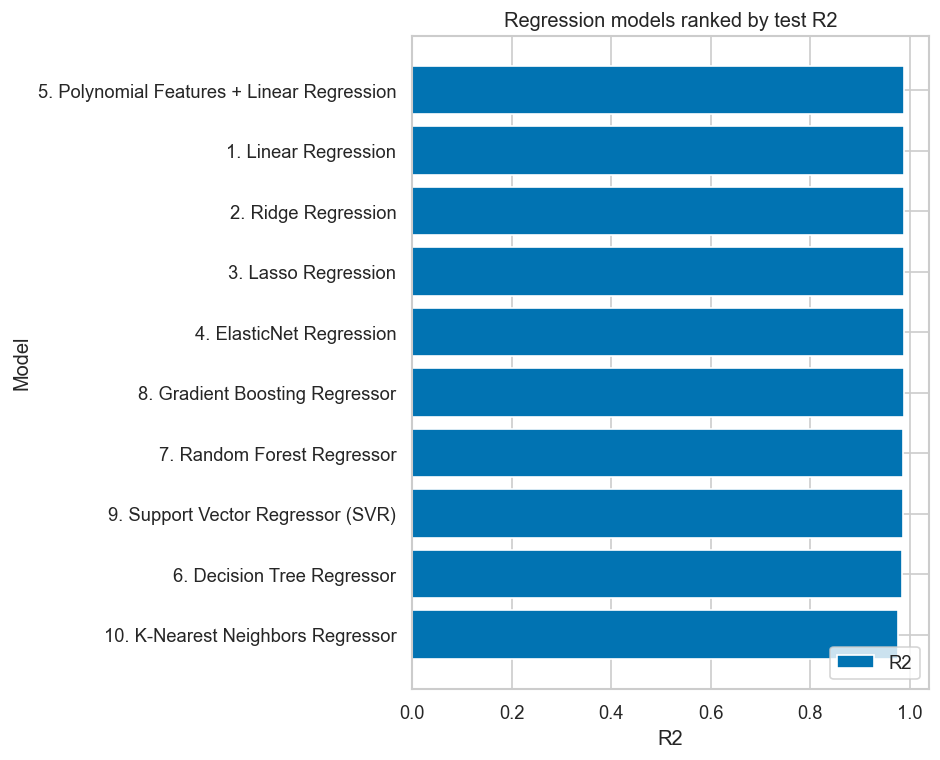

In [41]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Comparative results
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which model ranks first, and by how much does it beat the plain linear baseline?
> 2. Is that margin large enough to matter, given RMSE is in Performance-Index points?
> 3. What does it tell you that regularised linear models and tree ensembles land so close together?
> 4. Which model shows the largest gap between train R2 and test R2, and what is that gap called?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 6. Cross-validation  *(mandatory: 5-fold CV R2 for the two best models)*

Leading models are nominated using **training-side** cross-validation. The
held-out test set plays no part in selection.

**How 5-fold CV works:** split the training data into 5 equal parts; train on 4
and score on the 1 left out; repeat 5 times so each part is held out once;
average the 5 scores. Because the whole Pipeline is passed in, the scaler is
refitted inside every fold.

In [42]:
cv_all = ev.cv_scores(fitted, X_train, y_train, scoring="r2")
cv_all.drop(columns="fold_scores").sort_values("CV_mean", ascending=False)

  1. Linear Regression               r2 CV = 0.9887 (+/- 0.0003)
  2. Ridge Regression                r2 CV = 0.9887 (+/- 0.0003)
  3. Lasso Regression                r2 CV = 0.9887 (+/- 0.0003)
  4. ElasticNet Regression           r2 CV = 0.9886 (+/- 0.0002)
  5. Polynomial Features + Linear Regression r2 CV = 0.9886 (+/- 0.0003)
  6. Decision Tree Regressor         r2 CV = 0.9825 (+/- 0.0006)
  7. Random Forest Regressor         r2 CV = 0.9851 (+/- 0.0003)
  8. Gradient Boosting Regressor     r2 CV = 0.9879 (+/- 0.0003)
  9. Support Vector Regressor (SVR)  r2 CV = 0.9849 (+/- 0.0006)
  10. K-Nearest Neighbors Regressor  r2 CV = 0.9740 (+/- 0.0012)


,Model,scoring,folds,CV_mean,CV_std
0,1. Linear Regression,r2,5,0.988661,0.000283
1,2. Ridge Regression,r2,5,0.988661,0.000282
2,3. Lasso Regression,r2,5,0.988659,0.000275
3,4. ElasticNet Regression,r2,5,0.988632,0.000243
4,5. Polynomial Features + Linear Regression,r2,5,0.988618,0.000289
7,8. Gradient Boosting Regressor,r2,5,0.987947,0.000324
6,7. Random Forest Regressor,r2,5,0.985103,0.000307
8,9. Support Vector Regressor (SVR),r2,5,0.984944,0.000563
5,6. Decision Tree Regressor,r2,5,0.982533,0.000597
9,10. K-Nearest Neighbors Regressor,r2,5,0.973966,0.001248


In [43]:
leaders = cv_all.sort_values("CV_mean", ascending=False)["Model"].head(2).tolist()
print("two leading models, selected on TRAINING cross-validation:")
for l in leaders:
    print("   ", l)
cv_all[cv_all["Model"].isin(leaders)][["Model", "CV_mean", "CV_std", "fold_scores"]]

two leading models, selected on TRAINING cross-validation:
    1. Linear Regression
    2. Ridge Regression


,Model,CV_mean,CV_std,fold_scores
0,1. Linear Regression,0.988661,0.000283,"[0.98872, 0.98838, 0.98891, 0.98829, 0.989]"
1,2. Ridge Regression,0.988661,0.000282,"[0.98872, 0.98839, 0.98891, 0.98829, 0.989]"


## 7. Hyperparameter tuning  *(Rubric C3)*

`GridSearchCV` on at least two models. It tries every combination in the grid,
scoring each by cross-validation on the training data only, and keeps the best.

**If tuning does not improve a model, that is what gets reported.**

In [44]:
from src import regression_models as rm

tunable = [m for m in leaders if m in rm.PARAM_GRIDS]
for cand in rm.PARAM_GRIDS:                       # ensure at least two
    if len(tunable) >= 2:
        break
    if cand not in tunable:
        tunable.append(cand)
print("tuning:", tunable)
for t in tunable:
    print(f"  grid for {t}: {rm.PARAM_GRIDS[t]}")

tuning: ['2. Ridge Regression', '3. Lasso Regression']
  grid for 2. Ridge Regression: {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
  grid for 3. Lasso Regression: {'model__alpha': [0.001, 0.01, 0.1, 1.0]}


In [45]:
rows, tuned = {}, {}
for name in tunable:
    before_cv   = float(cv_all.loc[cv_all["Model"] == name, "CV_mean"].iloc[0])
    before_test = float(table.loc[table["Model"] == name, "R2"].iloc[0])
    gs = rm.tune(name, fitted[name], X_train, y_train)
    after = ev.regression_metrics(y_test, gs.best_estimator_.predict(X_test))
    rows[name] = {
        "best_params": gs.best_params_,
        "CV_R2_before": round(before_cv, 6),
        "CV_R2_after": round(gs.best_score_, 6),
        "HeldOut_R2_before": round(before_test, 6),
        "HeldOut_R2_after": round(after["R2"], 6),
        "improved_on_CV": bool(gs.best_score_ > before_cv),
    }
    tuned[name] = gs.best_estimator_
pd.DataFrame(rows).T

  [tuned] 2. Ridge Regression: best r2=0.9887 params={'model__alpha': 0.1}
  [tuned] 3. Lasso Regression: best r2=0.9887 params={'model__alpha': 0.001}


,best_params,CV_R2_before,CV_R2_after,HeldOut_R2_before,HeldOut_R2_after,improved_on_CV
2. Ridge Regression,{'model__alpha': 0.1},0.988661,0.988661,0.988982,0.988983,True
3. Lasso Regression,{'model__alpha': 0.001},0.988659,0.988661,0.988969,0.988982,True


> ### TEAM TO COMPLETE - Tuning outcome
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Did tuning change the score meaningfully, or only in the fourth or fifth decimal place?
> 2. What does the size of the change suggest about whether these models were under-regularised to begin with?
> 3. Would you ship the tuned or the default configuration, and why?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 8. Required visualisations  *(Rubric C4)*

**How to read a residual plot.** Residual = actual - predicted. Points should
scatter randomly around the zero line with roughly constant spread. A funnel
shape means the error grows with the prediction; a curve means a non-linear term
is missing.

In [46]:
best_name = table.sort_values("R2", ascending=False).iloc[0]["Model"]
best_model = tuned.get(best_name, fitted[best_name])
y_pred = best_model.predict(X_test)
print("best model on the held-out set:", best_name)

p1 = pl.residual_plot(y_test, y_pred, best_name, "nb_reg_residuals", "regression")
p2 = pl.predicted_vs_actual(y_test, y_pred, best_name, "nb_reg_pred_vs_actual", "regression")

best model on the held-out set: 5. Polynomial Features + Linear Regression
[fig] results\figures\regression\nb_reg_residuals.png
[fig] results\figures\regression\nb_reg_pred_vs_actual.png


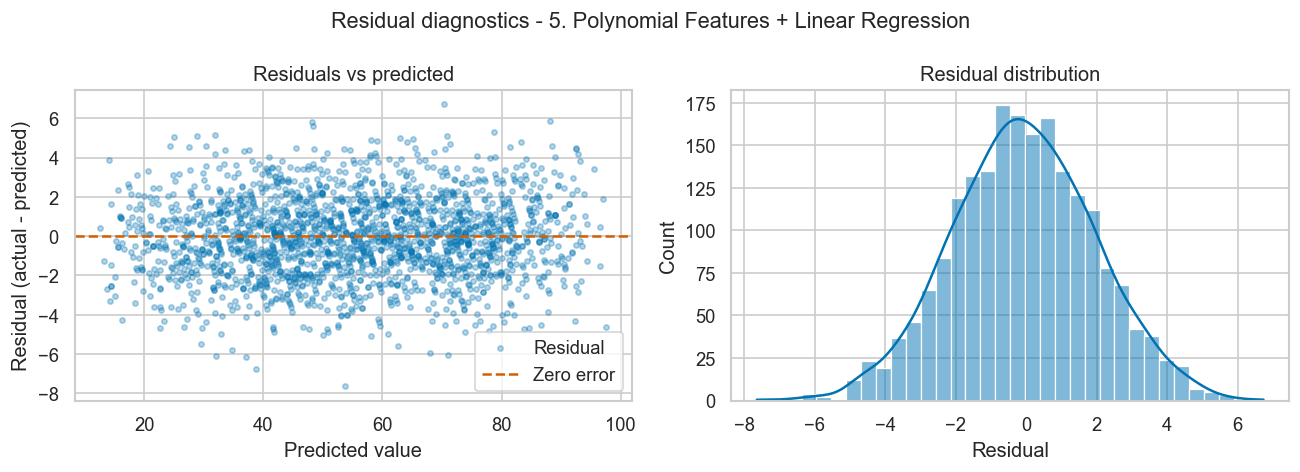

In [47]:
from IPython.display import Image, display
display(Image(filename=str(p1)))

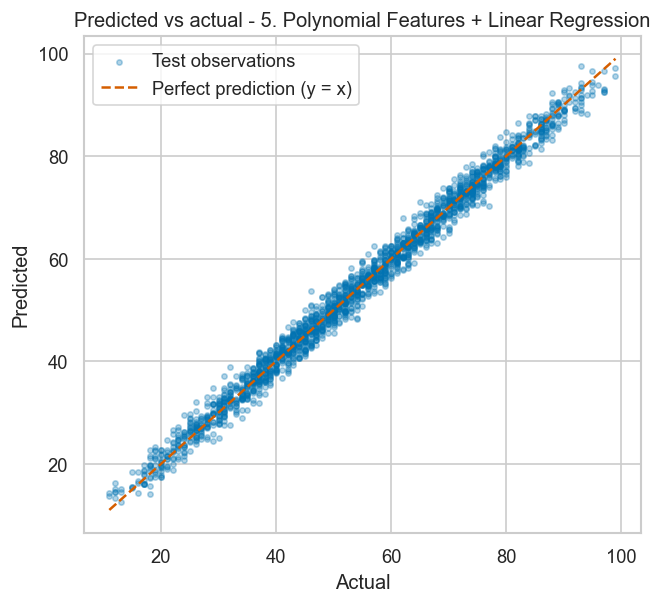

In [48]:
from IPython.display import Image, display
display(Image(filename=str(p2)))

> ### TEAM TO COMPLETE - Residual diagnostics
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Are residuals centred on zero with roughly constant spread, or do they fan out?
> 2. Does the residual histogram look approximately normal?
> 3. What would a visible curve here tell you about a missing feature or a missing non-linear term?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

In [49]:
imp = rm.tree_importances(fitted["7. Random Forest Regressor"])
p = pl.importance_plot(imp.values, imp.index,
                       "Random Forest Regressor - feature importance",
                       "nb_reg_feature_importance", "regression",
                       xlabel="Gini importance")
imp.round(4)

[fig] results\figures\regression\nb_reg_feature_importance.png


Previous Scores                     0.8468
Hours Studied                       0.1419
Sample Question Papers Practiced    0.0052
Sleep Hours                         0.0048
Extracurricular Activities_Yes      0.0013
dtype: float64

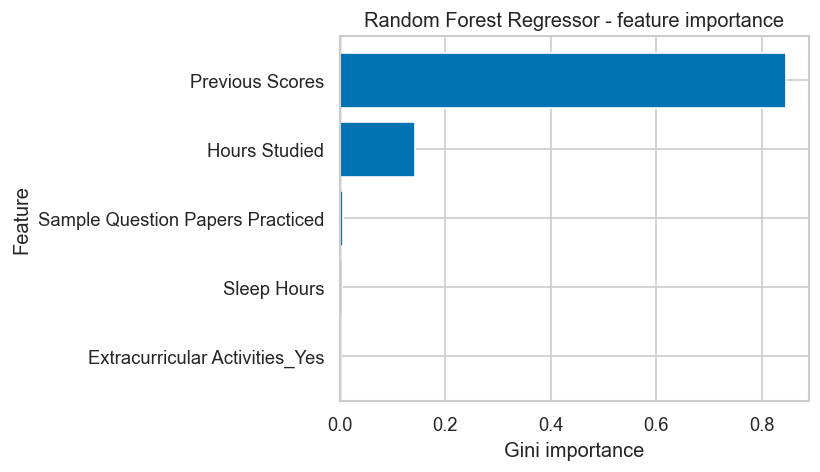

In [50]:
from IPython.display import Image, display
display(Image(filename=str(p)))

> ### TEAM TO COMPLETE - Feature importance vs linear coefficients
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Do the Random Forest importances rank the features the same way the linear coefficients did?
> 2. Where they disagree, which do you trust for this dataset, and why?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*

## 9. Review 1 - regression conclusion

> ### TEAM TO COMPLETE - Regression track conclusion
>
> *Left unwritten on purpose. Guidelines section 7.5 requires analysis and
> interpretation to be the team's own work. Replace the line at the bottom with
> your own observation.*
>
> **Guiding questions**
>
> 1. Which model do you nominate as final, and on what evidence (test metric, CV stability, simplicity, training cost)?
> 2. What is the practical meaning of the RMSE in Performance-Index points?
> 3. What is the main limitation of this dataset, given that it is synthetic?
> 4. What would you do next if you had another week?
>
> *(the numbers you need are already extracted in `docs/evidence_for_team_cells.md`)*
>
> ---
>
> *(your written observation here)*